<a href="https://colab.research.google.com/github/kojeda603/analisis_exploratorio_de_datos/blob/main/PARCIAL_FINAL_KEVIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA — Fertilidad de Suelos en Colombia (AGROSAVIA)

**Curso:** Análisis Exploratorio de Datos — Tarea individual (etapa final)
**Fuente:** Laboratorio de Química y Física de Suelos AGROSAVIA — datos.gov.co
**Dataset:** `Resultados_de_Análisis_de_Laboratorio_Suelos_en_Colombia_20260510.csv`

Este notebook desarrolla los **cuatro pasos obligatorios** de la guía:
1. Carga, inspección y tipado (con tratamiento documentado de valores no numéricos).
2. Distribuciones de parámetros de fertilidad.
3. Análisis espacial y por cultivo.
4. Relaciones entre nutrientes.



In [36]:
# ---- Setup ----
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ciencia_de_datos/Resultados_de_Análisis_de_Laboratorio_Suelos_en_Colombia_20260510.csv")

pd.set_option('display.max_columns', None)   # Mostrar TODAS las columnas
pd.set_option('display.width', None)         # Sin límite de ancho
pd.set_option('display.max_colwidth', None)  # No cortar contenido de celdas

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1761/3351325563.py:12: DtypeWarning: Columns (11,12,13,14,17,18,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ciencia_de_datos/Resultados_de_Análisis_de_Laboratorio_Suelos_en_Colombia_20260510.csv")


## Paso 1 — Carga, inspección y tipado


In [37]:
print("Dimensiones:", df.shape)
df.head(5)

Dimensiones: (92738, 32)


,Secuencial,Fecha de Análisis,Departamento,Municipio,Cultivo,Estado,Tiempo de establecimiento,Topografia,Drenaje,Riego,Fertilizantes aplicados,pH agua:suelo,Materia organica,Fósforo Bray II,Azufre Fosfato monocalcico,Acidez Intercambiable,Aluminio intercambiable,Calcio intercambiable,Magnesio intercambiable,Potasio intercambiable,Sodio intercambiable,capacidad de intercambio cationico,Conductividad electrica,Hierro disponible olsen,Cobre disponible,Manganeso disponible Olsen,Zinc disponible Olsen,Boro disponible,Hierro disponible doble acido,Cobre disponible doble acido,Manganeso disponible doble acido,Zinc disponible doble acido
0,1.0,7/01/2014,NARIÑO,SAN ANDRÉS DE TUMACO,No Indica,No indica,No indica,No indica,No indica,No indica,No indica,5.64,3.889,6.482,8.384,ND,ND,1.541,0.38,0.118,0.054,2.094,0.133,66.39,1.700,1.700,1.5,0.187,ND,ND,ND,ND
1,2.0,21/08/2014,HUILA,SANTA MARÍA,Granadilla,Establecido,De 1 a 5 años,Pendiente,Buen drenaje,No Tiene,No indica,4.24,2.287,520.1,90.3,2.021,1.483,2.932,0.925,2.131,0.043,8.054,2.749,250.9,3.7,29.4,28.70,2.084,ND,ND,ND,ND
2,3.0,22/08/2014,ANTIOQUIA,LIBORINA,Café,Por establecer,No indica,Pendiente,Mal drenaje,No Tiene,PRODUCCION,5.22,2.518,58.11,2.686,0.955,0.796,3.818,1.11,<0.09,0.01,5.985,0.328,390,11.10,8.299,5,0.085,ND,ND,ND,ND
3,4.0,22/08/2014,ANTIOQUIA,LIBORINA,Maracuyá,Por establecer,No indica,Ondulado,Mal drenaje,No Tiene,No indica,5.45,2.841,4.583,1.782,0,0,4.754,3.577,0.118,0.01,8.461,0.171,200,4.2,4.699,1,0.229,ND,ND,ND,ND
4,5.0,22/08/2014,ANTIOQUIA,LIBORINA,Café,Por establecer,No indica,Ondulado,Mal drenaje,No Tiene,PRODUCCION,5.43,2.703,5.512,3.138,0.150,0.109,7.338,3.022,0.096,0.032,10.64,0.323,117.9,3.8,4.600,0.700,0.139,ND,ND,ND,ND


In [38]:
df.columns

Index(['Secuencial', 'Fecha de Análisis', 'Departamento', 'Municipio',
       'Cultivo', 'Estado', 'Tiempo de establecimiento', 'Topografia',
       'Drenaje', 'Riego', 'Fertilizantes aplicados', 'pH agua:suelo',
       'Materia organica', 'Fósforo Bray II', 'Azufre Fosfato monocalcico',
       'Acidez Intercambiable', 'Aluminio intercambiable',
       'Calcio intercambiable', 'Magnesio intercambiable',
       'Potasio intercambiable', 'Sodio intercambiable',
       'capacidad de intercambio cationico', 'Conductividad electrica',
       'Hierro disponible olsen', 'Cobre disponible',
       'Manganeso disponible Olsen', 'Zinc disponible Olsen',
       'Boro disponible', 'Hierro disponible doble acido',
       'Cobre disponible doble acido', 'Manganeso disponible doble acido',
       'Zinc disponible doble  acido'],
      dtype='object')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92738 entries, 0 to 92737
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Secuencial                          92738 non-null  float64
 1   Fecha de Análisis                   92738 non-null  object 
 2   Departamento                        92738 non-null  object 
 3   Municipio                           92736 non-null  object 
 4   Cultivo                             92738 non-null  object 
 5   Estado                              92738 non-null  object 
 6   Tiempo de establecimiento           92738 non-null  object 
 7   Topografia                          92738 non-null  object 
 8   Drenaje                             92738 non-null  object 
 9   Riego                               92738 non-null  object 
 10  Fertilizantes aplicados             92738 non-null  object 
 11  pH agua:suelo                       92738

In [40]:
# Columnas NO numéricas:
no_numericas = ['Secuencial', 'Fecha de Análisis', 'Departamento', 'Municipio',
                'Cultivo', 'Estado', 'Tiempo de establecimiento', 'Topografia',
                'Drenaje', 'Riego', 'Fertilizantes aplicados']

# El resto SÍ son numéricas
num_cols = [c for c in df.columns if c not in no_numericas]

print(num_cols)

['pH agua:suelo', 'Materia organica', 'Fósforo Bray II', 'Azufre Fosfato monocalcico', 'Acidez Intercambiable', 'Aluminio intercambiable', 'Calcio intercambiable', 'Magnesio intercambiable', 'Potasio intercambiable', 'Sodio intercambiable', 'capacidad de intercambio cationico', 'Conductividad electrica', 'Hierro disponible olsen', 'Cobre disponible', 'Manganeso disponible Olsen', 'Zinc disponible Olsen', 'Boro disponible', 'Hierro disponible doble acido', 'Cobre disponible doble acido', 'Manganeso disponible doble acido', 'Zinc disponible doble \xa0acido']


In [41]:
df.columns = df.columns.str.replace("\xa0", " ", regex=False).str.replace(r"\s+", " ", regex=True).str.strip()

num_cols = ['pH agua:suelo',
       'Materia organica', 'Fósforo Bray II', 'Azufre Fosfato monocalcico',
       'Acidez Intercambiable', 'Aluminio intercambiable',
       'Calcio intercambiable', 'Magnesio intercambiable',
       'Potasio intercambiable', 'Sodio intercambiable',
       'capacidad de intercambio cationico', 'Conductividad electrica',
       'Hierro disponible olsen', 'Cobre disponible',
       'Manganeso disponible Olsen', 'Zinc disponible Olsen',
       'Boro disponible', 'Hierro disponible doble acido',
       'Cobre disponible doble acido', 'Manganeso disponible doble acido',
       'Zinc disponible doble acido']

In [42]:
filas = []
for c in num_cols:
    sucios = df[pd.to_numeric(df[c], errors="coerce").isna()][c].dropna()
    top = sucios.value_counts().head(3)
    ejemplos = ", ".join(f"{v} ({n})" for v, n in top.items())
    filas.append({"columna": c, "total_sucios": len(sucios), "top_3": ejemplos})

resumen_sucios = pd.DataFrame(filas)
resumen_sucios

,columna,total_sucios,top_3
0,pH agua:suelo,11,"<3.80 (6), >10.00 (4), 4..01 (1)"
1,Materia organica,73,"<0.38 (69), ND (2), >44.82 (2)"
2,Fósforo Bray II,15033,"<3.87 (11366), <1.29 (2097), ND (1469)"
3,Azufre Fosfato monocalcico,1562,"ND (1499), <0.01 (61), <2.50 (2)"
4,Acidez Intercambiable,45130,ND (45130)
5,Aluminio intercambiable,45130,ND (45130)
6,Calcio intercambiable,5170,"<1.12 (2340), < 0.5 (1592), <0.59 (1232)"
7,Magnesio intercambiable,3875,<0.20 (3875)
8,Potasio intercambiable,15167,<0.09 (15167)
9,Sodio intercambiable,44774,"<0.14 (33005), < 0.1 (11763), < 0.0 (6)"


In [10]:
filas = []
for c in num_cols:
    serie = df[c].astype(str).str.strip()

    filas.append({
        "columna":       c,
        "ND/No indica":  serie.isin(["ND", "NA", "No indica", ""]).sum(),
        "<LOD (\"<x\")": serie.str.startswith("<").sum(),
        ">max (\">x\")": serie.str.startswith(">").sum(),
        "coma decimal":  serie.str.contains(",", na=False).sum(),
        "negativos":     serie.str.startswith("-").sum(),

    })

doc = pd.DataFrame(filas).set_index("columna")
doc

,ND/No indica,"<LOD (""<x"")",">max ("">x"")",coma decimal,negativos
columna,,,,,
pH agua:suelo,0,6,4,0,0
Materia organica,2,69,2,0,0
Fósforo Bray II,1469,13564,0,0,0
Azufre Fosfato monocalcico,1499,63,0,0,1
Acidez Intercambiable,45130,0,0,0,0
Aluminio intercambiable,45130,0,0,0,0
Calcio intercambiable,0,5170,0,0,0
Magnesio intercambiable,0,3875,0,0,0
Potasio intercambiable,0,15167,0,0,0


In [11]:
def limpiar_numerico(serie):
    serie = serie.astype(str).str.strip()
    serie = serie.replace({"ND": np.nan, "No indica": np.nan, "NA": np.nan, "": np.nan})
    serie = serie.str.replace(" ", "", regex=False)   # quita espacios internos
    serie = serie.str.replace(",", ".", regex=False)  # coma decimal → punto

    # Marca cuáles eran "<x" antes de quitarles el símbolo
    mask_lod = serie.str.startswith("<", na=False)
    serie = serie.str.lstrip("<>")                    # quita < o > del inicio

    out = pd.to_numeric(serie, errors="coerce")       # convierte; lo no parseable → NaN
    out = out.mask(mask_lod, out / 2)                 # <x → x/2 (mitad del LOD)
    out = out.mask(out < 0.00001, np.nan)                   # negativos → NaN (no tienen sentido físico)

    return out

In [12]:
for c in num_cols:
    df[c] = limpiar_numerico(df[c])

In [13]:
filas = []
for c in num_cols:
    serie = df[c].astype(str).str.strip()
    filas.append({
        "columna":       c,
        "ND/No indica":  serie.isin(["ND", "NA", "No indica", ""]).sum(),
        "<LOD (\"<x\")": serie.str.startswith("<").sum(),
        ">max (\">x\")": serie.str.startswith(">").sum(),
        "coma decimal":  serie.str.contains(",", na=False).sum(),
        "negativos":     serie.str.startswith("-").sum(),
        "NaN final":     df[c].isna().sum(),
    })

doc = pd.DataFrame(filas).set_index("columna")
doc

,ND/No indica,"<LOD (""<x"")",">max ("">x"")",coma decimal,negativos,NaN final
columna,,,,,,
pH agua:suelo,0,0,0,0,0,1
Materia organica,0,0,0,0,0,3
Fósforo Bray II,0,0,0,0,0,1469
Azufre Fosfato monocalcico,0,0,0,0,0,1500
Acidez Intercambiable,0,0,0,0,0,45732
Aluminio intercambiable,0,0,0,0,0,48047
Calcio intercambiable,0,0,0,0,0,0
Magnesio intercambiable,0,0,0,0,0,0
Potasio intercambiable,0,0,0,0,0,0


In [14]:
df[num_cols].dtypes

,0
pH agua:suelo,float64
Materia organica,float64
Fósforo Bray II,float64
Azufre Fosfato monocalcico,float64
Acidez Intercambiable,float64
Aluminio intercambiable,float64
Calcio intercambiable,float64
Magnesio intercambiable,float64
Potasio intercambiable,float64
Sodio intercambiable,float64


In [15]:
faltantes = pd.DataFrame({
    "no nulos":  df[num_cols].notna().sum(),
    "nulos":     df[num_cols].isna().sum(),
    "% nulos":   (df[num_cols].isna().mean() * 100).round(2),
}).sort_values("% nulos", ascending=False)

faltantes

,no nulos,nulos,% nulos
Zinc disponible doble acido,4779,87959,94.85
Hierro disponible doble acido,4786,87952,94.84
Manganeso disponible doble acido,4786,87952,94.84
Cobre disponible doble acido,4786,87952,94.84
Aluminio intercambiable,44691,48047,51.81
Acidez Intercambiable,47006,45732,49.31
Zinc disponible Olsen,86856,5882,6.34
Cobre disponible,86864,5874,6.33
Hierro disponible olsen,86866,5872,6.33
Manganeso disponible Olsen,86866,5872,6.33


In [16]:
desc = df[num_cols].describe().T
desc["mediana"] = df[num_cols].median()
desc = desc[["count", "mean", "mediana", "std", "min", "25%", "75%", "max"]]
desc.columns = ["n", "media", "mediana", "desv_std", "min", "p25", "p75", "max"]
desc.round(3)

,n,media,mediana,desv_std,min,p25,p75,max
pH agua:suelo,92737.0,5.708,5.470,1.021,1.900,4.960,6.260,10.57
Materia organica,92735.0,4.409,2.750,4.597,0.010,1.675,5.127,75.04
Fósforo Bray II,91269.0,28.705,8.403,74.550,0.088,3.061,26.180,3015.00
Azufre Fosfato monocalcico,91238.0,14.255,6.202,56.070,0.005,3.735,11.320,4862.00
Acidez Intercambiable,47006.0,2.329,1.720,2.347,0.010,0.860,2.970,40.89
Aluminio intercambiable,44691.0,1.975,1.419,2.037,0.008,0.690,2.540,36.60
Calcio intercambiable,92738.0,7.387,4.130,9.411,0.028,1.412,9.609,171.80
Magnesio intercambiable,92738.0,2.040,1.020,2.744,0.006,0.400,2.480,68.52
Potasio intercambiable,92738.0,0.368,0.220,0.706,0.045,0.118,0.423,64.06
Sodio intercambiable,92731.0,0.218,0.070,0.945,0.002,0.070,0.166,99.11


In [17]:
# Descriptivos para todas las fisicoquímicas
desc = df[num_cols].describe(percentiles=[.25, .5, .75]).T
desc["mediana"] = df[num_cols].median()
desc = desc[["count","mean","mediana","std","min","25%","75%","max"]].round(3)
desc.columns = ["n","media","mediana","desv_std","min","p25","p75","max"]
desc

,n,media,mediana,desv_std,min,p25,p75,max
pH agua:suelo,92737.0,5.708,5.470,1.021,1.900,4.960,6.260,10.57
Materia organica,92735.0,4.409,2.750,4.597,0.010,1.675,5.127,75.04
Fósforo Bray II,91269.0,28.705,8.403,74.550,0.088,3.061,26.180,3015.00
Azufre Fosfato monocalcico,91238.0,14.255,6.202,56.070,0.005,3.735,11.320,4862.00
Acidez Intercambiable,47006.0,2.329,1.720,2.347,0.010,0.860,2.970,40.89
Aluminio intercambiable,44691.0,1.975,1.419,2.037,0.008,0.690,2.540,36.60
Calcio intercambiable,92738.0,7.387,4.130,9.411,0.028,1.412,9.609,171.80
Magnesio intercambiable,92738.0,2.040,1.020,2.744,0.006,0.400,2.480,68.52
Potasio intercambiable,92738.0,0.368,0.220,0.706,0.045,0.118,0.423,64.06
Sodio intercambiable,92731.0,0.218,0.070,0.945,0.002,0.070,0.166,99.11


### 1.3 Valores fuera de rango agronómicamente plausible

Aplicamos límites de referencia agronómicos (Jaramillo, *Introducción a la ciencia del suelo*; IGAC).

In [18]:

plausible = {
    # --- Generales ---
    "pH agua:suelo":                       (3.5, 10.5),   # adim.
    "Materia organica":                    (0,    30),    # % (Histosoles fuera)
    "Conductividad electrica":             (0,    30),    # dS/m

    # --- Macronutrientes / acidez ---
    "Fósforo Bray II":                     (0,    300),   # mg/kg
    "Azufre Fosfato monocalcico":          (0,    150),   # mg/kg (S-SO4 disponible)
    "Acidez Intercambiable":               (0,    25),    # cmol/kg
    "Aluminio intercambiable":             (0,    20),    # cmol/kg

    # --- Bases intercambiables y CIC ---
    "Calcio intercambiable":               (0,    80),    # cmol/kg
    "Magnesio intercambiable":             (0,    25),    # cmol/kg
    "Potasio intercambiable":              (0,    5),     # cmol/kg
    "Sodio intercambiable":                (0,    15),    # cmol/kg
    "capacidad de intercambio cationico":  (0,    80),    # cmol/kg

    # --- Micronutrientes Olsen / Olsen-EDTA ---
    "Hierro disponible olsen":             (0,    3000),   # mg/kg
    "Cobre disponible":                    (0,    60),    # mg/kg
    "Manganeso disponible Olsen":          (0,    300),   # mg/kg
    "Zinc disponible Olsen":               (0,    80),    # mg/kg
    "Boro disponible":                     (0,    10),    # mg/kg

    # --- Micronutrientes doble ácido (Mehlich) ---
    # Mehlich extrae más que Olsen, especialmente en suelos ácidos
    "Hierro disponible doble acido":       (0,    500),   # mg/kg
    "Cobre disponible doble acido":        (0,    50),    # mg/kg
    "Manganeso disponible doble acido":    (0,    300),   # mg/kg
    "Zinc disponible doble acido":        (0,    80),    # mg/kg  (ojo: doble espacio en el nombre)
}


oor = []
for c, (lo, hi) in plausible.items():
    mask = df[c].notna() & ((df[c] < lo) | (df[c] > hi))
    oor.append((c, lo, hi, int(mask.sum())))

pd.DataFrame(oor, columns=["variable", "min_plaus", "max_plaus", "n_fuera_rango"])

,variable,min_plaus,max_plaus,n_fuera_rango
0,pH agua:suelo,3.5,10.5,14
1,Materia organica,0.0,30.0,192
2,Conductividad electrica,0.0,30.0,14
3,Fósforo Bray II,0.0,300.0,1016
4,Azufre Fosfato monocalcico,0.0,150.0,1037
5,Acidez Intercambiable,0.0,25.0,32
6,Aluminio intercambiable,0.0,20.0,44
7,Calcio intercambiable,0.0,80.0,52
8,Magnesio intercambiable,0.0,25.0,32
9,Potasio intercambiable,0.0,5.0,149


## Paso 2 — Distribuciones de parámetros de fertilidad

### 2.1 Histogramas

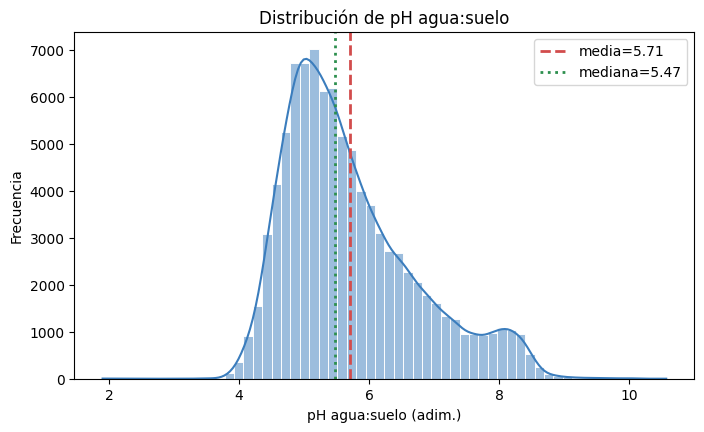

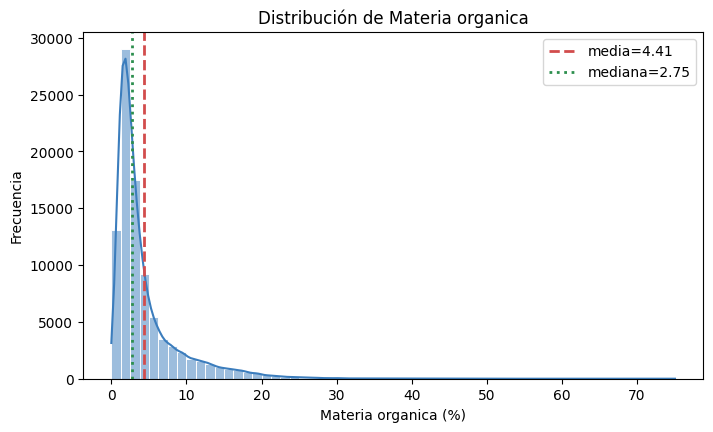

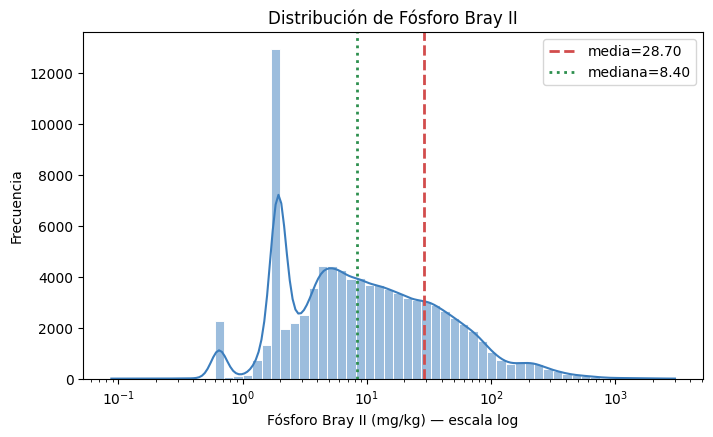

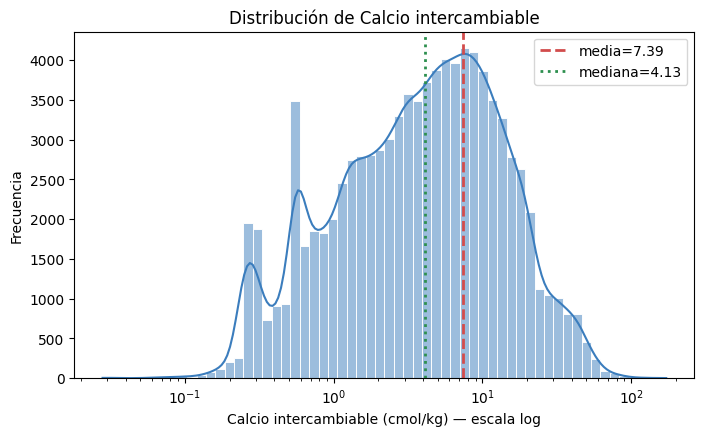

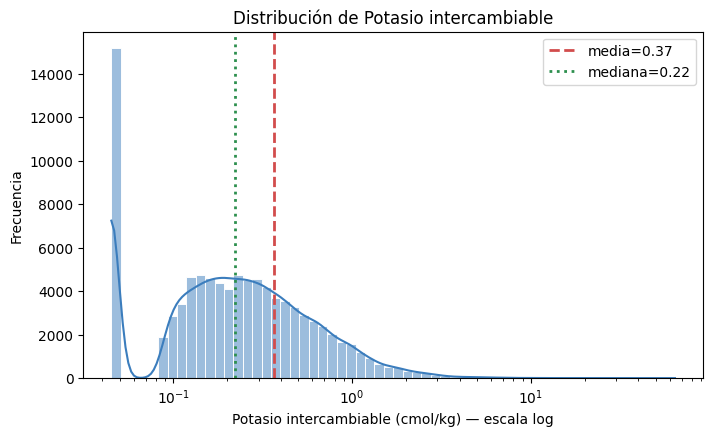

In [19]:
def hist(col, bins=50, log=False, unit=""):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    data = df[col].dropna()
    if log:
        data = data[data > 0]   # quita ceros y negativos (no se pueden poner en log)

    sns.histplot(data, bins=bins, kde=True, color="#3b7dbd", edgecolor="white",
                 ax=ax, log_scale=log)   # ← log_scale en X

    ax.axvline(data.mean(),   color="#d24c4c", lw=2, ls="--", label=f"media={data.mean():.2f}")
    ax.axvline(data.median(), color="#2d8f4e", lw=2, ls=":",  label=f"mediana={data.median():.2f}")

    ax.set_xlabel(f"{col} ({unit})" + (" — escala log" if log else ""))
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"Distribución de {col}")
    ax.legend()
    plt.show()

hist("pH agua:suelo",          bins=60, unit="adim.")
hist("Materia organica",       bins=60, unit="%")
hist("Fósforo Bray II",        bins=60, log=True, unit="mg/kg")
hist("Calcio intercambiable",  bins=60, log=True, unit="cmol/kg")
hist("Potasio intercambiable", bins=60, log=True, unit="cmol/kg")




> **Interpretación:**
> - **pH** ~normal-asimétrico centrado en **5.5** → predominio de suelos ácidos colombianos.
> - **Materia orgánica** muy sesgada a la derecha (mediana 2.75 %, máx 75 %).
>   Coexisten suelos minerales degradados y andisoles/órganicos andinos.
> - **Fósforo Bray II** distribución log-normal extrema: la mediana (8.4 mg/kg) está
>   por debajo del nivel crítico para casi todos los cultivos (≈15–20 mg/kg).
> - **K y Ca intercambiables** log-normales típicas de cationes en solución.

### 2.2 Clasificación agronómica de pH

In [20]:
bins   = [-np.inf, 4.5, 5.5, 6.5, 7.5, 8.5, np.inf]
labels = ["Muy ácido", "Ácido", "Lig. ácido", "Neutro", "Alcalino", "Muy alcalino"]

df["clase_pH"] = pd.cut(
    df["pH agua:suelo"],
    bins=bins,
    labels=labels,
    right=False,   # intervalos [lo, hi) — equivale a tu '<' estricto
    ordered=True
)

# El resumen sale en una línea, con orden categórico automático
resumen_ph = (df["clase_pH"]
              .value_counts()
              .reindex(labels)
              .to_frame("n"))
resumen_ph["pct"] = (100 * resumen_ph["n"] / resumen_ph["n"].sum()).round(2)
resumen_ph

,n,pct
clase_pH,,
Muy ácido,5802,6.26
Ácido,41611,44.87
Lig. ácido,26519,28.60
Neutro,11534,12.44
Alcalino,6588,7.10
Muy alcalino,683,0.74


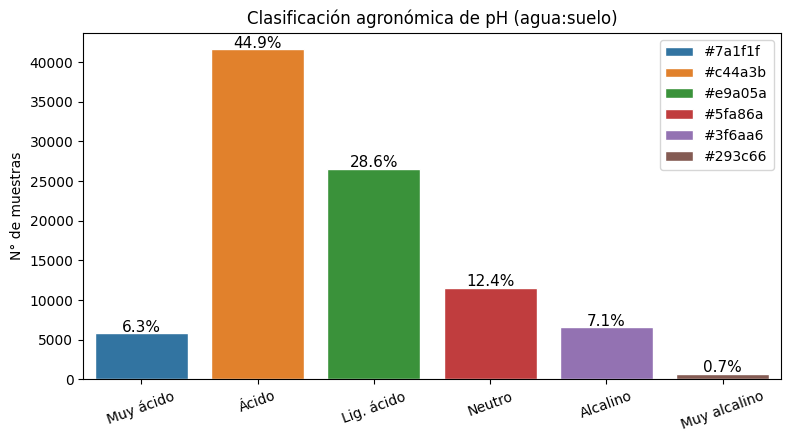

In [21]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#7a1f1f", "#c44a3b", "#e9a05a", "#5fa86a", "#3f6aa6", "#293c66"]

sns.barplot(x=resumen_ph.index, y=resumen_ph["n"], hue=colors, ax=ax, edgecolor="white")

for i, (n, p) in enumerate(zip(resumen_ph["n"], resumen_ph["pct"])):
    ax.text(i, n + 200, f"{p:.1f}%", ha="center", fontsize=11)

ax.set_ylabel("N° de muestras")
ax.set_xlabel("")
ax.set_title("Clasificación agronómica de pH (agua:suelo)")
ax.tick_params(axis="x", rotation=20)
plt.show()

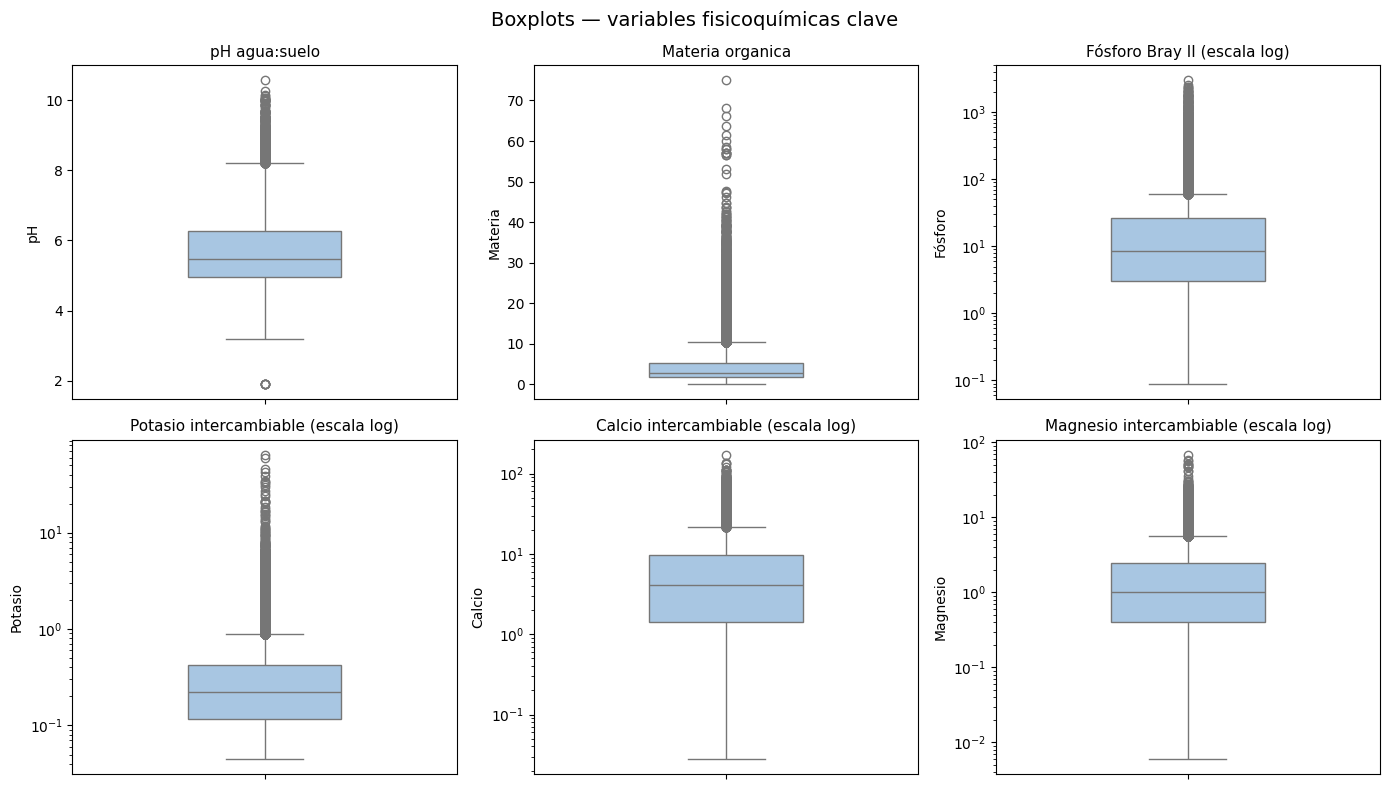

In [22]:
cols_iqr = ["pH agua:suelo", "Materia organica", "Fósforo Bray II",
            "Potasio intercambiable", "Calcio intercambiable", "Magnesio intercambiable"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, c in zip(axes.ravel(), cols_iqr):
    data = df[c].dropna()
    sns.boxplot(y=data, ax=ax, color="#9ec6ec", width=0.4)
    ax.set_title(c, fontsize=11)
    ax.set_ylabel(c.split()[0])

    # Escala log para los muy sesgados
    if data.max() / max(data.median(), 0.01) > 30:
        ax.set_yscale("log")
        ax.set_title(f"{c} (escala log)", fontsize=11)

fig.suptitle("Boxplots — variables fisicoquímicas clave", fontsize=14)
plt.tight_layout()
plt.show()

## Paso 3 — Análisis espacial y por cultivo

### 3.1 Comparación entre departamentos (top 8 por n° de muestras)

In [23]:
top_dep = df["Departamento"].value_counts().head(8).index.tolist()
dep_stats = (df[df["Departamento"].isin(top_dep)]
             .groupby("Departamento")
             .agg(n=("Secuencial","count"),
                  pH_media=("pH agua:suelo","mean"),
                  pH_mediana=("pH agua:suelo","median"),
                  MO_media=("Materia organica","mean"),
                  MO_mediana=("Materia organica","median"))
             .round(2)
             .sort_values("n", ascending=False))
dep_stats

,n,pH_media,pH_mediana,MO_media,MO_mediana
Departamento,,,,,
CUNDINAMARCA,14016,5.63,5.39,7.23,5.19
VALLE DEL CAUCA,9244,6.32,6.17,4.44,3.13
META,8800,5.04,4.96,2.34,2.10
ANTIOQUIA,7907,5.38,5.25,6.40,3.79
NARIÑO,5961,5.99,5.82,5.11,3.52
BOYACÁ,5269,5.36,5.19,6.32,4.76
SANTANDER,4693,5.49,5.20,3.62,2.79
NORTE DE SANTANDER,3900,5.55,5.42,2.69,2.21


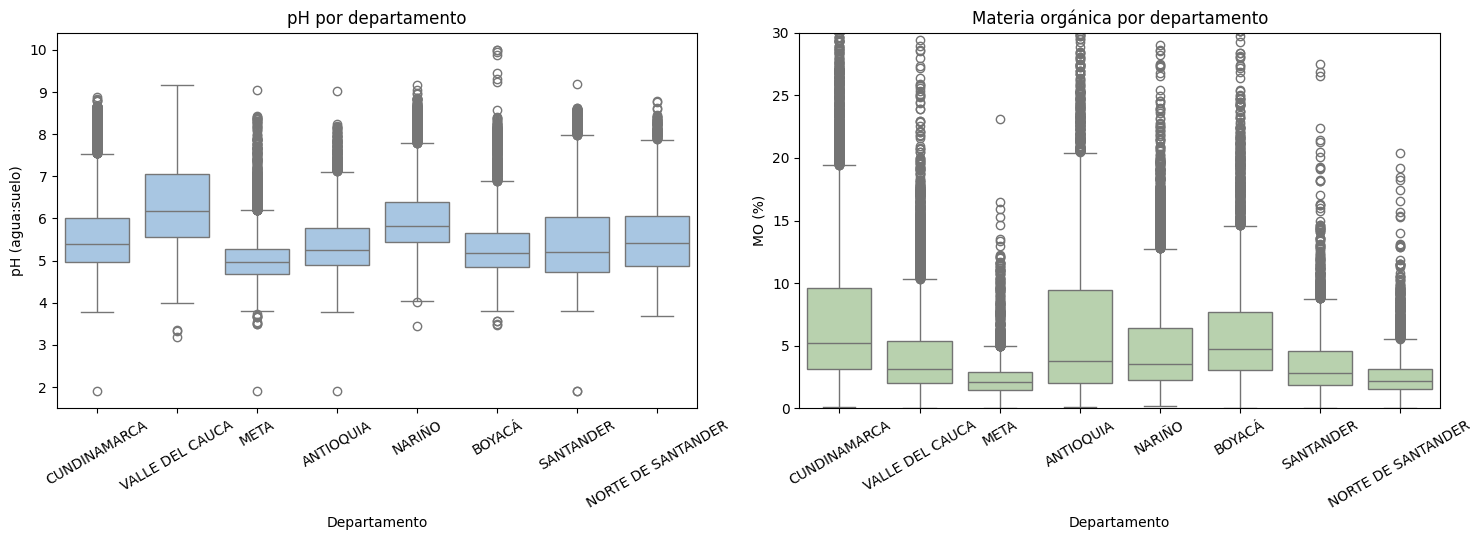

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sub = df[df["Departamento"].isin(top_dep)]
orden_dep = dep_stats.index.tolist()
sns.boxplot(data=sub, x="Departamento", y="pH agua:suelo", order=orden_dep,
            ax=axes[0], color="#9ec6ec")
axes[0].set_title("pH por departamento"); axes[0].set_ylabel("pH (agua:suelo)")
axes[0].tick_params(axis="x", rotation=30)
sns.boxplot(data=sub, x="Departamento", y="Materia organica", order=orden_dep,
            ax=axes[1], color="#b6d7a8")
axes[1].set_title("Materia orgánica por departamento"); axes[1].set_ylabel("MO (%)")
axes[1].set_ylim(0,30); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

> **Patrón espacial:**
> - **Meta** y **Antioquia** tienen los suelos más ácidos (mediana pH ≈ 5.0–5.25) —
>   coherente con las llanuras de Oxisoles/Ultisoles altamente meteorizados y
>   los suelos lateríticos de Antioquia.
> - **Valle del Cauca** muestra el pH más alto (≈ 6.2) por la influencia de
>   sedimentos aluviales y la práctica intensiva de encalado en caña.
> - **Cundinamarca** y **Antioquia** acumulan más MO (climas fríos/altos andes).

### 3.2 Perfiles de fertilidad de los cinco cultivos más frecuentes

In [25]:
top_cult = (df[~df["Cultivo"].isin(["No Indica","No indica"])]["Cultivo"]
            .value_counts().head(5).index.tolist())
cult_stats = (df[df["Cultivo"].isin(top_cult)]
              .groupby("Cultivo")
              .agg(n=("Secuencial","count"),
                   pH=("pH agua:suelo","mean"),
                   MO=("Materia organica","mean"),
                   P=("Fósforo Bray II","median"),
                   K=("Potasio intercambiable","median"))
              .round(2)
              .sort_values("n", ascending=False))
cult_stats

,n,pH,MO,P,K
Cultivo,,,,,
Cacao,11104,5.34,2.76,5.05,0.13
Pastos,7542,5.75,5.68,11.46,0.28
Aguacate,5915,5.68,6.81,6.47,0.26
Pasto,5886,5.62,4.44,5.36,0.20
Café,5080,5.38,5.57,7.81,0.25


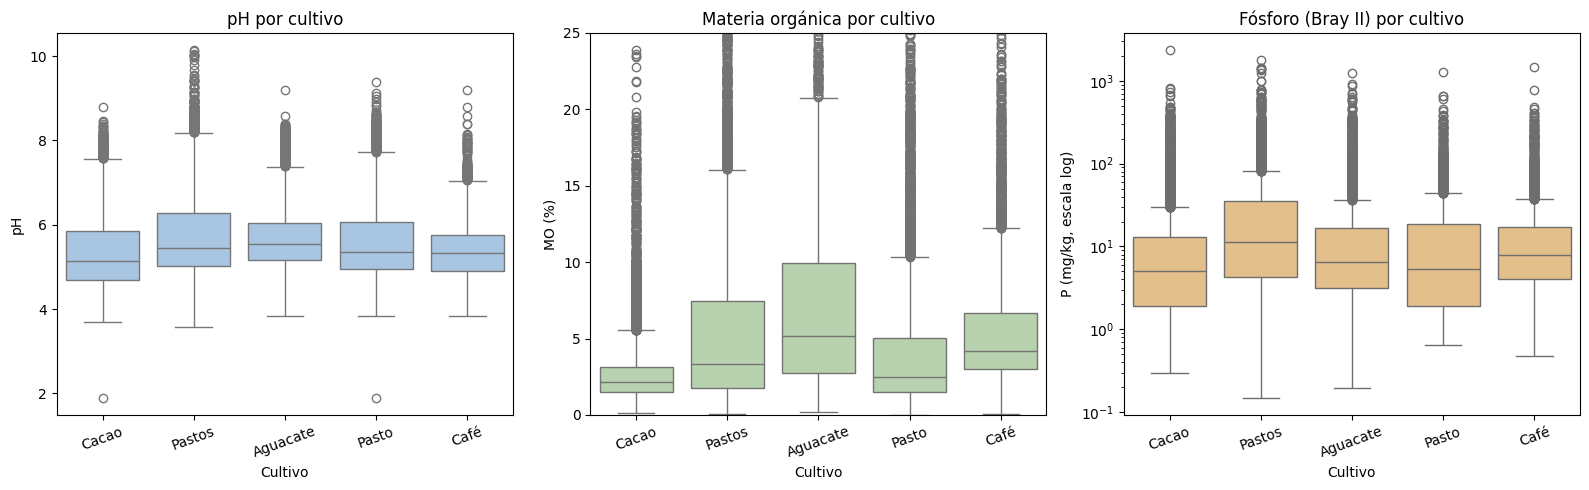

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sub_c = df[df["Cultivo"].isin(top_cult)]
sns.boxplot(data=sub_c, x="Cultivo", y="pH agua:suelo", order=top_cult, ax=axes[0], color="#9ec6ec")
axes[0].set_title("pH por cultivo"); axes[0].set_ylabel("pH"); axes[0].tick_params(axis="x", rotation=20)
sns.boxplot(data=sub_c, x="Cultivo", y="Materia organica", order=top_cult, ax=axes[1], color="#b6d7a8")
axes[1].set_title("Materia orgánica por cultivo"); axes[1].set_ylabel("MO (%)")
axes[1].set_ylim(0,25); axes[1].tick_params(axis="x", rotation=20)
sns.boxplot(data=sub_c, x="Cultivo", y="Fósforo Bray II", order=top_cult, ax=axes[2], color="#f1c27d")
axes[2].set_yscale("log"); axes[2].set_title("Fósforo (Bray II) por cultivo")
axes[2].set_ylabel("P (mg/kg, escala log)"); axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

> **Lectura:**
> - **Cacao** se asocia con los pH más bajos (≈ 5.3) y P medianamente bajo,
>   consistente con su distribución en pie de monte amazónico y Catatumbo.
> - **Pastos/Pasto** muestran mayor variabilidad y P relativamente más alto
>   (manejo con fertilización en sistemas intensivos).
> - **Aguacate** acumula la MO más alta (zonas frías de Antioquia/Caldas).

### 3.3 Drenaje vs. materia orgánica

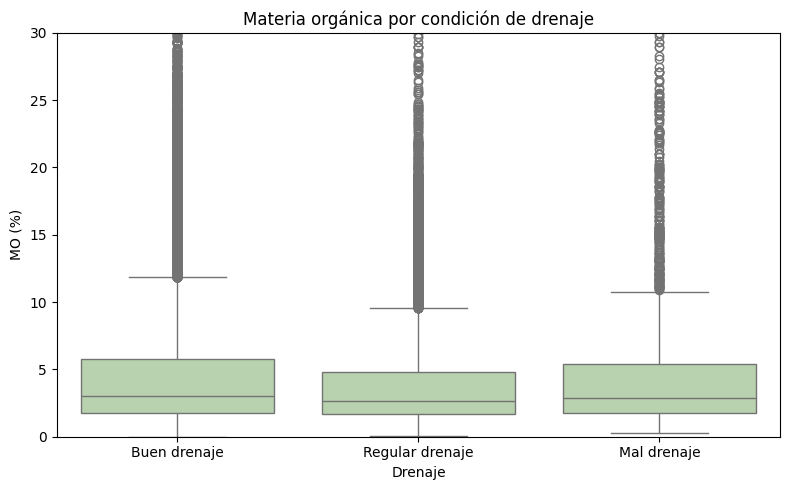

,count,mean,median,std
Drenaje,,,,
Buen drenaje,49806,4.77,2.99,4.77
Regular drenaje,14229,4.12,2.69,4.21
Mal drenaje,2667,4.84,2.85,5.48


In [27]:
drenaje_orden = ["Buen drenaje","Regular drenaje","Mal drenaje"]
sub_dr = df[df["Drenaje"].isin(drenaje_orden)]
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=sub_dr, x="Drenaje", y="Materia organica",
            order=drenaje_orden, ax=ax, color="#b6d7a8")
ax.set_title("Materia orgánica por condición de drenaje")
ax.set_ylabel("MO (%)"); ax.set_ylim(0,30)
plt.tight_layout(); plt.show()

sub_dr.groupby("Drenaje")["Materia organica"].agg(["count","mean","median","std"]).reindex(drenaje_orden).round(2)

> Contrario a la expectativa intuitiva (mal drenaje → más MO por anaerobiosis), las
> medianas son similares (~2.7–3.0 %). El **buen drenaje** muestra ligeramente más
> MO en promedio, indicando que en este dataset la MO está más asociada a clima
> (altitud, temperatura) que a régimen hídrico local.

## Paso 4 — Relaciones entre nutrientes

### 4.1 Matriz de correlación (Spearman)

Usamos **Spearman** porque varias variables son log-normales con outliers extremos
(Pearson sería sensible a la cola).

In [28]:
g = sns.clustermap(
    corr,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    figsize=(14, 12),
    dendrogram_ratio=(0.12, 0.12),
    cbar_pos=(0.02, 0.85, 0.03, 0.12),   # mueve la barra a la esquina sup-izq
    linewidths=0.3, linecolor="white",
)

# Etiquetas X horizontales y un poco más chicas
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(),
                             rotation=45, ha="right", fontsize=9)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(),
                             rotation=0, fontsize=9)

g.fig.suptitle("Clustermap — variables fisicoquímicas agrupadas por similitud",
               y=1.02, fontsize=14)
plt.show()

NameError: name 'corr' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(df["pH agua:suelo"], df["Fósforo Bray II"],
           alpha=0.07, s=10, c="#2c5d8f")
ax.set_yscale("log")
ax.set_xlabel("pH agua:suelo")
ax.set_ylabel("Fósforo Bray II (mg/kg, log)")
ax.set_title("Relación pH ↔ disponibilidad de fósforo (Bray II)")

# Mediana de P por bin de pH (línea de tendencia)
bins = np.arange(df["pH agua:suelo"].min(), df["pH agua:suelo"].max() + 0.5, 0.5)
medians = (df.assign(ph_bin=pd.cut(df["pH agua:suelo"], bins=bins))
             .groupby("ph_bin", observed=True)["Fósforo Bray II"].median())
centers = [i.mid for i in medians.index]
ax.plot(centers, medians.values, color="#d24c4c", lw=2.5, marker="o",
        label="Mediana de P por bin de pH")

ax.legend()
plt.tight_layout()
plt.show()

rho = df[["pH agua:suelo", "Fósforo Bray II"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman pH vs P = {rho:.3f}")

In [ ]:
# Clasificación más precisa: separa "no fertiliza" de "no respondió"
mapeo_fert = {
    "NO INDICA":      "Sin dato",
    "":               "Sin dato",
    "NO FERTILIZAN":  "No fertilizado",
    "NINGUNO":        "No fertilizado",
    "NO TIENE":       "No fertilizado",
}

def clasif_fert(v):
    if pd.isna(v):
        return "Sin dato"
    u = str(v).strip().upper()
    return mapeo_fert.get(u, "Fertilizado")

df["grupo_fert"] = df["Fertilizantes aplicados"].apply(clasif_fert)

# Tabla comparativa con conteo, porcentaje y medianas
fert_cmp = (df.groupby("grupo_fert")
              .agg(n=("Secuencial", "count"),
                   pH=("pH agua:suelo", "median"),
                   MO=("Materia organica", "median"),
                   P=("Fósforo Bray II", "median"),
                   K=("Potasio intercambiable", "median"),
                   Ca=("Calcio intercambiable", "median"),
                   Mg=("Magnesio intercambiable", "median"))
              .round(2))

fert_cmp["%"] = (100 * fert_cmp["n"] / fert_cmp["n"].sum()).round(1)
fert_cmp = fert_cmp[["n", "%", "pH", "MO", "P", "K", "Ca", "Mg"]]
fert_cmp

In [ ]:
variables = ["pH agua:suelo", "Materia organica",
             "Fósforo Bray II", "Potasio intercambiable"]

melt = df[df["grupo_fert"].isin(["Fertilizado", "No fertilizado"])].melt(
    id_vars="grupo_fert", value_vars=variables,
    var_name="variable", value_name="valor")

mediana = melt.groupby("variable")["valor"].transform("median")
q1 = melt.groupby("variable")["valor"].transform("quantile", q=0.25)
q3 = melt.groupby("variable")["valor"].transform("quantile", q=0.75)
melt["z"] = (melt["valor"] - mediana) / (q3 - q1)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=melt, x="variable", y="z", hue="grupo_fert",
            palette={"Fertilizado": "#3b7dbd", "No fertilizado": "#d4a55a"},
            showfliers=False, width=0.6, ax=ax)

ax.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.6)
ax.set_ylim(-3, 4)
ax.set_ylabel("Valor estandarizado (z robusto)")
ax.set_xlabel("")
ax.set_title("Perfil nutricional: suelos fertilizados vs no fertilizados")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="", loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

4. personal
